In [1]:
# Block 0: Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [2]:
# Block 1: Setup Kaggle API and Download Dataset directly to Colab

# 1. Install Kaggle library
!pip install -q kaggle

# 2. Upload your kaggle.json file (API token)
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 3. Move the uploaded file to the correct hidden folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download the dataset (Replace with the exact Kaggle dataset path if different)
print("Downloading dataset from Kaggle...")
!kaggle datasets download -d anasmohammedtahir/covidqu

# 5. Unzip the dataset silently (-q) to a specific folder
print("Extracting dataset...")
!unzip -q covidqu.zip -d /content/COVID-QU-Ex

print("Dataset downloaded and extracted successfully in Colab temporary storage!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/anasmohammedtahir/covidqu
License(s): CC-BY-SA-4.0
100% 1.15G/1.15G [00:15<00:00, 39.8MB/s]
100% 1.15G/1.15G [00:15<00:00, 79.7MB/s]
Extracting dataset...
Dataset downloaded and extracted successfully in Colab temporary storage!


In [3]:
# Block 2: Auto-discover Dataset Paths based on actual structure
import os
import glob

BASE_DIR = '/content/COVID-QU-Ex/Infection Segmentation Data/Infection Segmentation Data'

image_paths = []
mask_paths = []

search_pattern = f"{BASE_DIR}/**/images/*.*"
all_images = glob.glob(search_pattern, recursive=True)

for img_path in all_images:

    parent_dir = os.path.dirname(os.path.dirname(img_path))
    filename = os.path.basename(img_path)


    mask_path_1 = os.path.join(parent_dir, 'masks', filename)
    mask_path_2 = os.path.join(parent_dir, 'infection masks', filename)

    if os.path.exists(mask_path_1):
        image_paths.append(img_path)
        mask_paths.append(mask_path_1)
    elif os.path.exists(mask_path_2):
        image_paths.append(img_path)
        mask_paths.append(mask_path_2)

print(f"Total Valid Images Found: {len(image_paths)}")
print(f"Total Valid Masks Found: {len(mask_paths)}")

Total Valid Images Found: 5826
Total Valid Masks Found: 5826


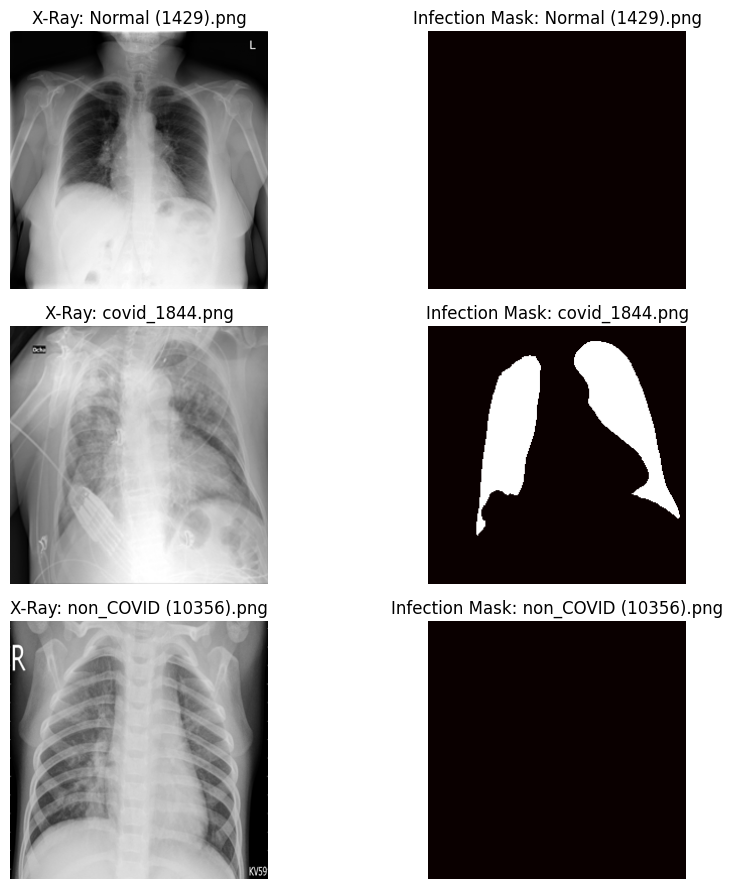

In [4]:
# Block 3: Visualize random samples from the dataset
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def explore_dataset(num_samples=3):
    if 'image_paths' not in globals() or len(image_paths) == 0:
        print("Error!")
        return

    plt.figure(figsize=(10, num_samples * 3))

    for i in range(num_samples):

        idx = np.random.randint(0, len(image_paths))

        img_path = image_paths[idx]
        mask_path = mask_paths[idx]


        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Plot Image
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.title(f"X-Ray: {os.path.basename(img_path)}")
        plt.imshow(img, cmap='gray')
        plt.axis('off')

        # Plot Mask
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.title(f"Infection Mask: {os.path.basename(mask_path)}")
        plt.imshow(mask, cmap='hot')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

explore_dataset()

In [11]:
# Block 4: Data Preprocessing with Data Filtering
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 1

infected_image_paths = [p for p in image_paths if 'COVID-19' in p]
infected_mask_paths = [p for p in mask_paths if 'COVID-19' in p]

# Fallback just in case the folder naming is slightly different
if len(infected_image_paths) < 100:
    print("Warning: Not enough COVID-19 images found. Using the general dataset.")
    infected_image_paths = image_paths
    infected_mask_paths = mask_paths

# Limit the number of images (subset) to prevent Colab RAM crashes
subset_size = min(1000, len(infected_image_paths))

# Split into train/test sets
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    infected_image_paths[:subset_size],
    infected_mask_paths[:subset_size],
    test_size=0.2,
    random_state=42
)

def load_data(img_list, mask_list):
    X = np.zeros((len(img_list), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(mask_list), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.float32)

    for n, (img_path, mask_path) in enumerate(zip(img_list, mask_list)):
        # Read and resize original image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        X[n] = np.expand_dims(img, axis=-1) / 255.0

        # Read and resize mask image
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        Y[n] = np.expand_dims(mask, axis=-1) / 255.0

    return X, Y

print(f"Loading {subset_size} strictly infected images into memory...")
X_train, Y_train = load_data(train_imgs, train_masks)
X_test, Y_test = load_data(test_imgs, test_masks)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

Loading 1000 strictly infected images into memory...
X_train shape: (800, 256, 256, 1)
Y_train shape: (800, 256, 256, 1)


In [12]:
# Block 5: Build the U-Net Architecture
def build_unet(input_shape):
    inputs = Input(input_shape)

    # Encoder (Contraction Path)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)

    # Decoder (Expansion Path)
    u4 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u4)
    c4 = Dropout(0.1)(c4)
    c4 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)

    u5 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = concatenate([u5, c1], axis=3)
    c5 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u5)
    c5 = Dropout(0.1)(c5)
    c5 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # Output Layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

model = build_unet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256, 256,  │          0 │ conv2d_11[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │      2,320 │ dropout_5[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_13[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │      9,248 │ dropout_6[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │     36,928 │ dropout_7[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 128, 128,  │      8,224 │ conv2d_16[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     18,464 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │      9,248 │ dropout_8[0][0] 

 Total params: 116,753 (456.07 KB)

 Trainable params: 116,753 (456.07 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Block 6: Compile and Train the Model using Dice Loss
import tensorflow.keras.backend as K
import tensorflow as tf

# Define Dice Coefficient to measure overlap
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Define Dice Loss (We want to minimize this)
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# Compile model with new loss and metric
model.compile(optimizer='adam', loss=dice_loss, metrics=[dice_coef, 'accuracy'])

# Callbacks to save the best model
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_dice_coef', mode='max'),
    tf.keras.callbacks.ModelCheckpoint('covid_unet_best.keras', save_best_only=True, monitor='val_dice_coef', mode='max')
]

print("Starting training with Dice Loss...")
# Train the model
history = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    batch_size=16,
    epochs=25,
    callbacks=callbacks
)

Starting training with Dice Loss...
Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - accuracy: 0.2146 - dice_coef: 0.2328 - loss: 0.7672 - val_accuracy: 0.1995 - val_dice_coef: 0.2645 - val_loss: 0.7355
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.2596 - dice_coef: 0.2688 - loss: 0.7312 - val_accuracy: 0.2842 - val_dice_coef: 0.2855 - val_loss: 0.7145
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.3000 - dice_coef: 0.2708 - loss: 0.7292 - val_accuracy: 0.3009 - val_dice_coef: 0.2848 - val_loss: 0.7152
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.3270 - dice_coef: 0.2862 - loss: 0.7138 - val_accuracy: 0.3857 - val_dice_coef: 0.3085 - val_loss: 0.6915
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.4073 - dice_coef: 0.3048 - loss: 0.6952 - val_accuracy: 0.4401 - val_dice_coef: 0.3284 - val_loss: 0.6716
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.4646 - dice_coef: 0.3330 - loss: 0.66

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


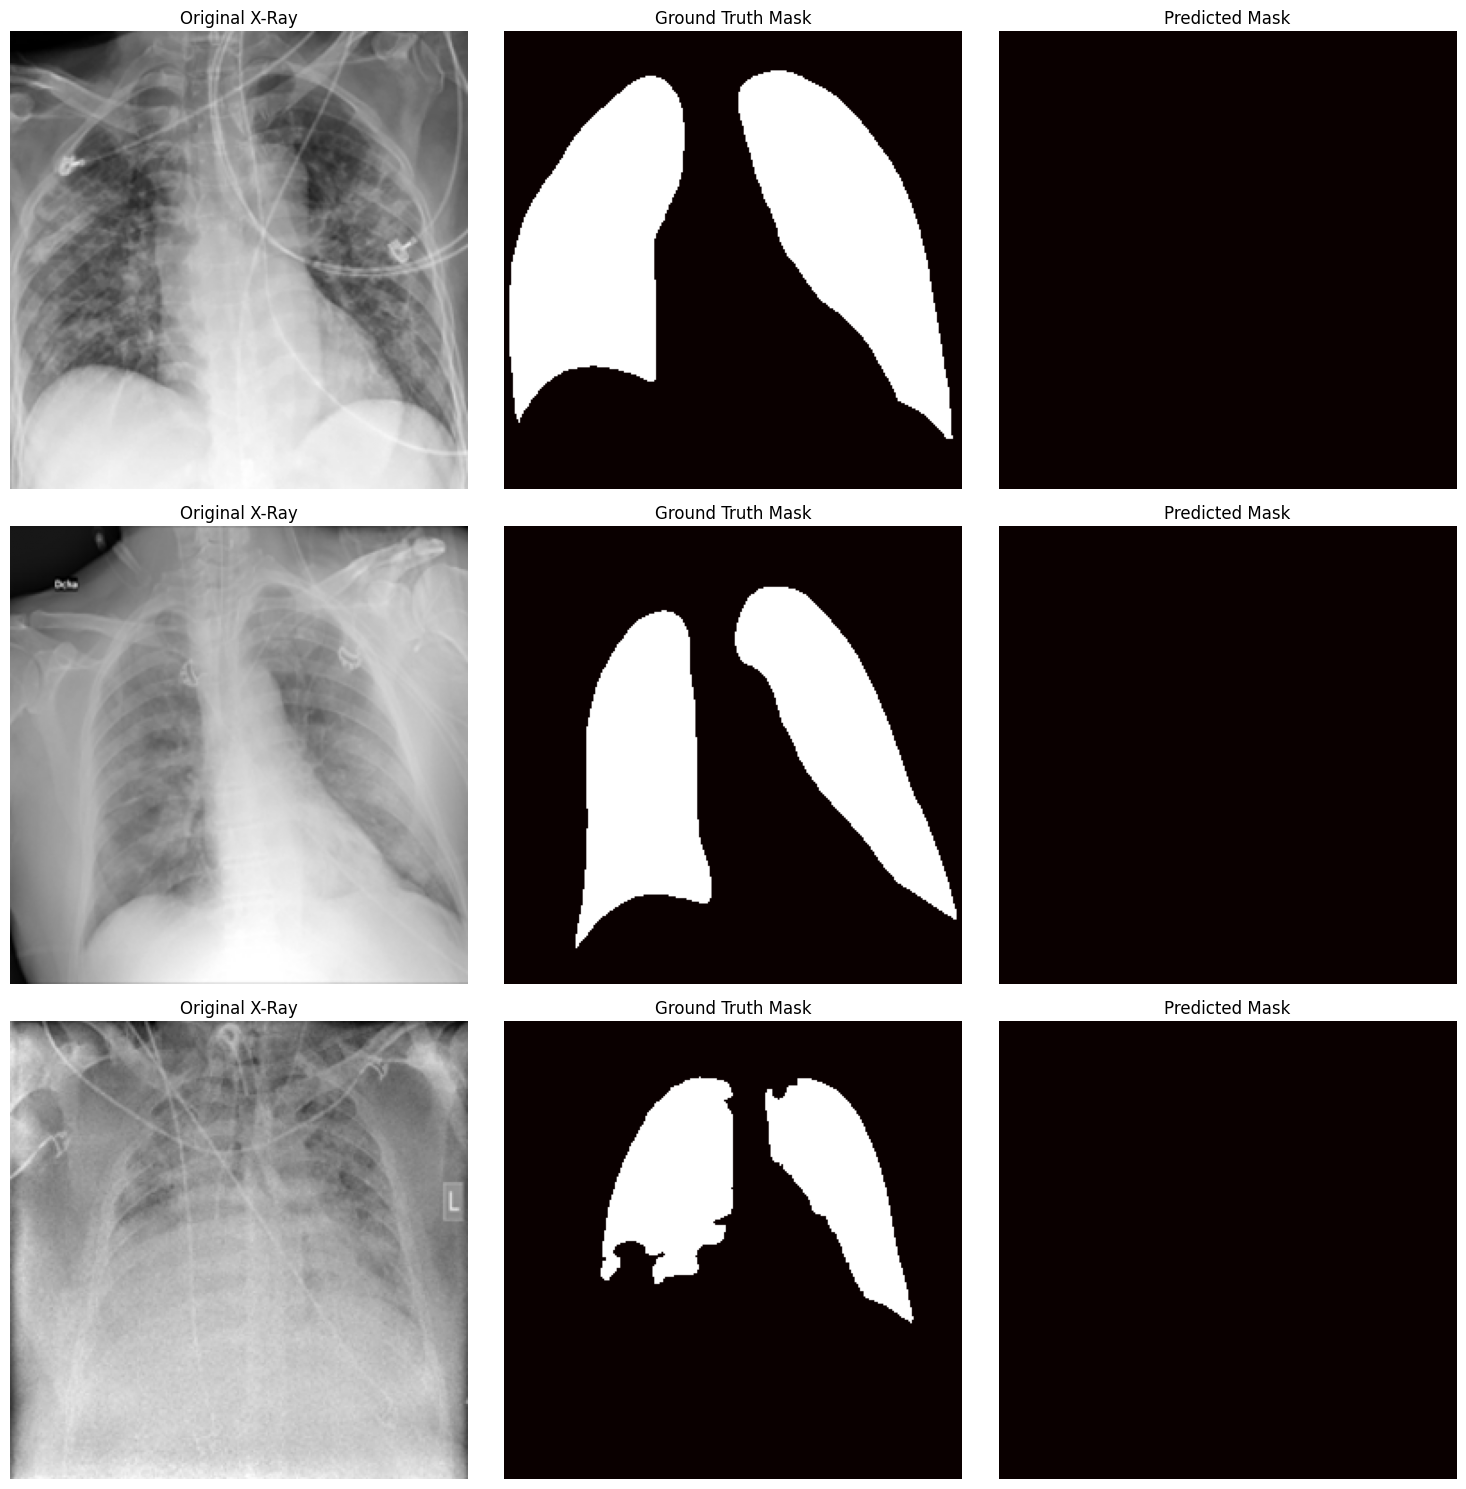

In [14]:
# Block 7: Predict and Visualize Results
# Predict on test set
preds_test = model.predict(X_test, verbose=1)
# Threshold predictions to create binary masks
preds_test_t = (preds_test > 0.5).astype(np.uint8)

def plot_predictions(num_samples=3):
    plt.figure(figsize=(15, num_samples * 5))

    for i in range(num_samples):
        idx = np.random.randint(0, len(X_test))

        # Plot Original Image
        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.title("Original X-Ray")
        plt.imshow(X_test[idx].squeeze(), cmap='gray')
        plt.axis('off')

        # Plot Ground Truth
        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.title("Ground Truth Mask")
        plt.imshow(Y_test[idx].squeeze(), cmap='hot')
        plt.axis('off')

        # Plot Prediction
        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.title("Predicted Mask")
        plt.imshow(preds_test_t[idx].squeeze(), cmap='hot')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_predictions()